# Parameter tuning for Terschelling

## Paths and settings

In [33]:
new_initial_state = True
new_tuning = True

In [34]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_tc = path_to_data_folder + '01_tides/output/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '12_13_Ters_DEM/input/'
path_output = path_to_data_folder + '12_13_Ters_DEM/output/'
path_altimetry_output = path_to_data_folder + '11_Ters_altimetry/output/'
path_transect_polys = path_to_data_folder + '05_Ters_transect_polys/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2023_n53.5439_s53.2693_w5.0194_e5.6607.nc'
fn_ddtm = 'DeltaDTM_v1_0_N53E005.tif'

epsg_local = 28992 # Amersfoort
epsg = 4326 # WGS84

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [35]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [37]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [38]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [39]:
# Tidal correction
fn = 'tides_ters.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [40]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'/1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


### Shoreline outlier rejection

In [41]:
med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=100, transect_length=5000, smooth_factor=100)
t_factor = 1 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, med_sl, epsg, t_factor)
pickle.dump(c_shorelines_corr, open(path_output + 'c_shorelines_corr.pkl', 'wb'))

19.0% of shoreline points were discarded.


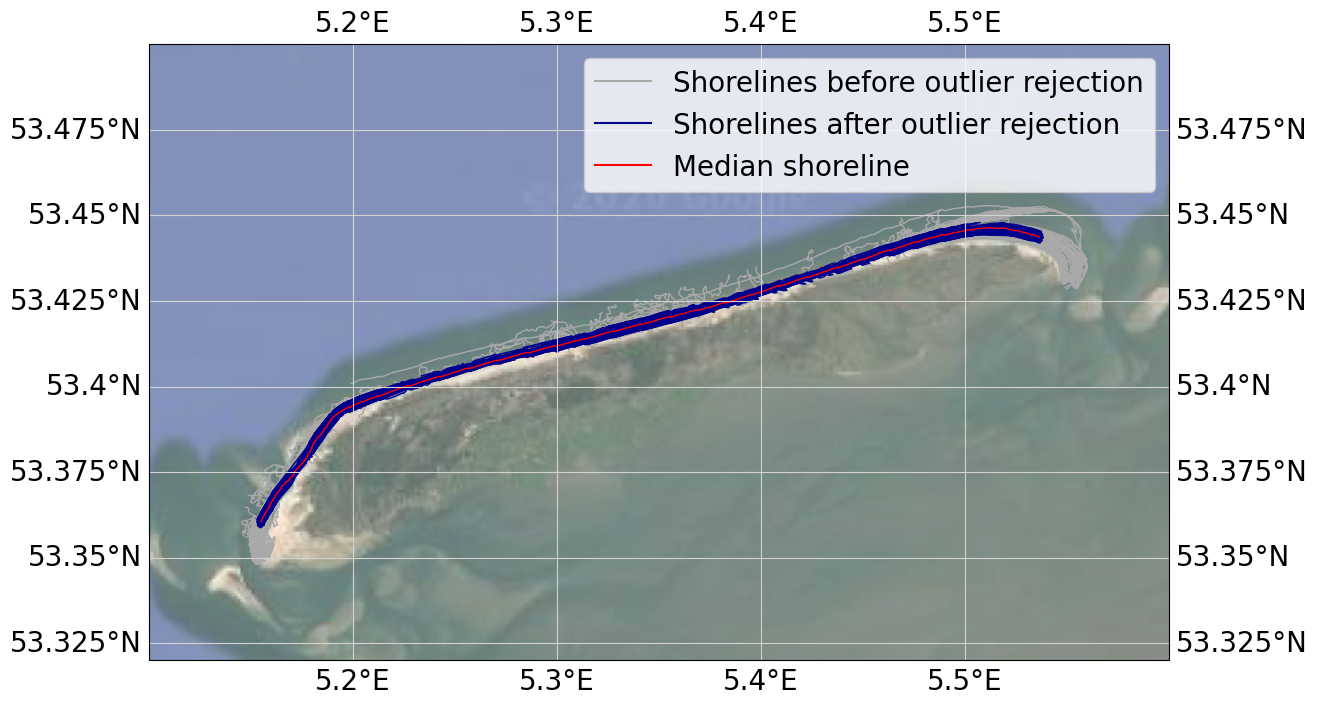

In [42]:
# Visual inspection of shoreline outlier rejectio
projection = ccrs.PlateCarree()

request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='red')

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkgrey', zorder=1, alpha=1)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

legend_elements = [
Line2D([0], [0], color='darkgrey', label='Shorelines before outlier rejection'),
Line2D([0], [0], color='darkblue', label='Shorelines after outlier rejection'),
Line2D([0], [0], color='red', label='Median shoreline'),
]
ax.legend(handles=legend_elements)

plt.savefig(f'{path_output}shoreline_outlier_rejection.png', dpi=300, bbox_inches='tight')

## Initial state

In [43]:
resolution = CD_geometry.dist_meter_to_dist_deg(100) # [deg], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_100m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    # Target area: polgon around the shorelines
    poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=resolution)
    pickle.dump(poly_sl_corr, open(path_output + f'poly_sl_{epsg}.pkl', 'wb'))

    # Initial state
    smooth_factor = 100 # Smoothing of shorelines used to compute the median shoreline
    CD_kalman.initial_state(poly_sl_corr, med_sl, epsg, resolution, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)
else:
    poly_sl_corr = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))

Bias GEBCO - DeltaDTM: -0.73 m (based on 156 overlapping points (interpolated to target grid))
Done. Needed  0.13 minutes.


Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [44]:
init = xr.open_dataset(path_output+fn_init).squeeze()

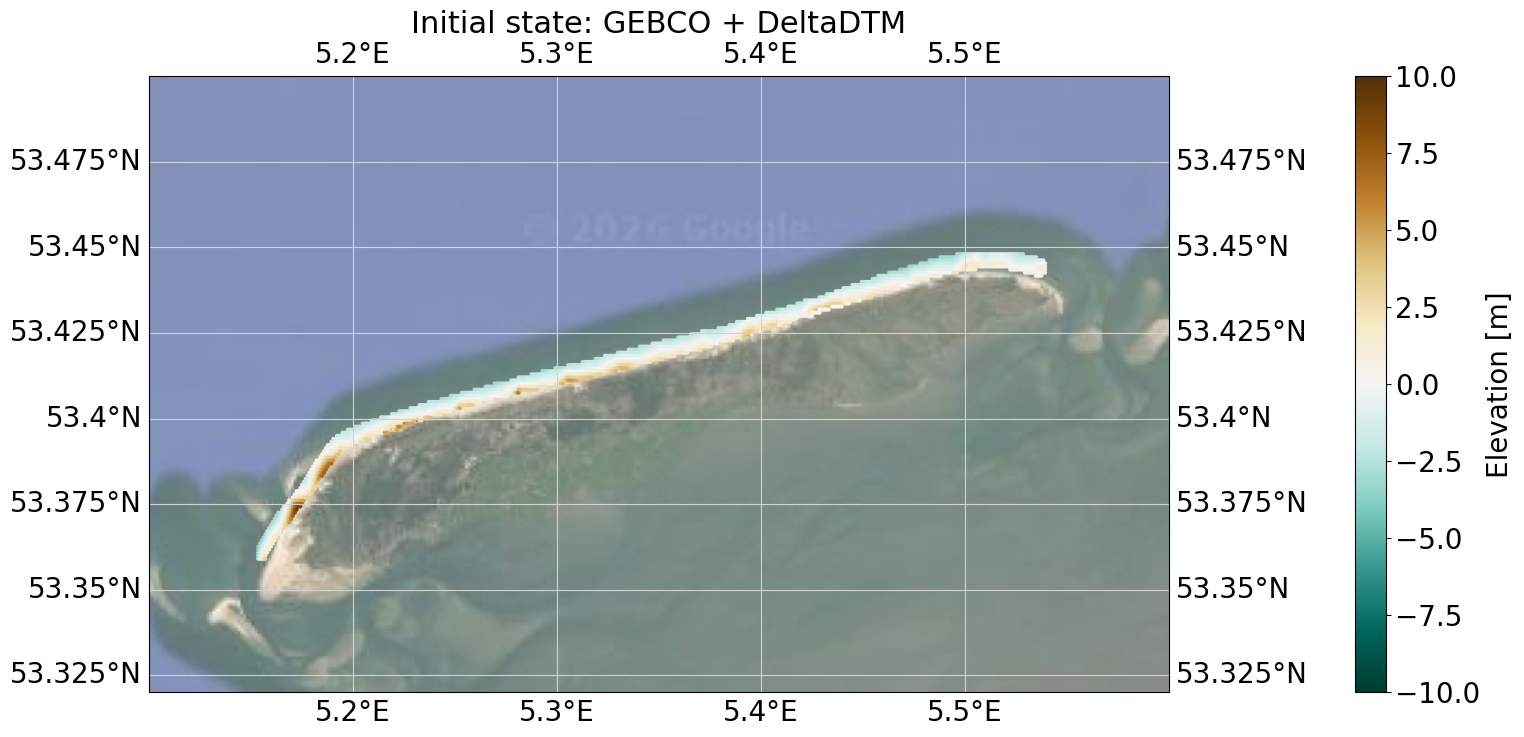

In [45]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

# %matplotlib qt5
projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=15,
                  cmap='BrBG_r', vmin=-10, vmax=10)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=22);

plt.savefig(f'{path_output}initial_state.png', dpi=300, bbox_inches='tight')

## Jarkus data

In [15]:
jarkus_gdf = CD_jarkus_tools.get_jarkus_data(path_input_general, year_start, year_end, poly_shorelines, init)

In [16]:
# thin out the grid so that there are approximately 700 values left, as evenly spaced as possible
temp = init.band_data.values.reshape(-1)
num_values = len(temp[~np.isnan(temp)])

thin_out_factor = int(len(jarkus_gdf) / num_values)
jarkus_gdf = jarkus_gdf.iloc[::thin_out_factor]

jarkus_gdf = jarkus_gdf.set_crs('4326')
jarkus_gdf = jarkus_gdf.reset_index(drop=True)

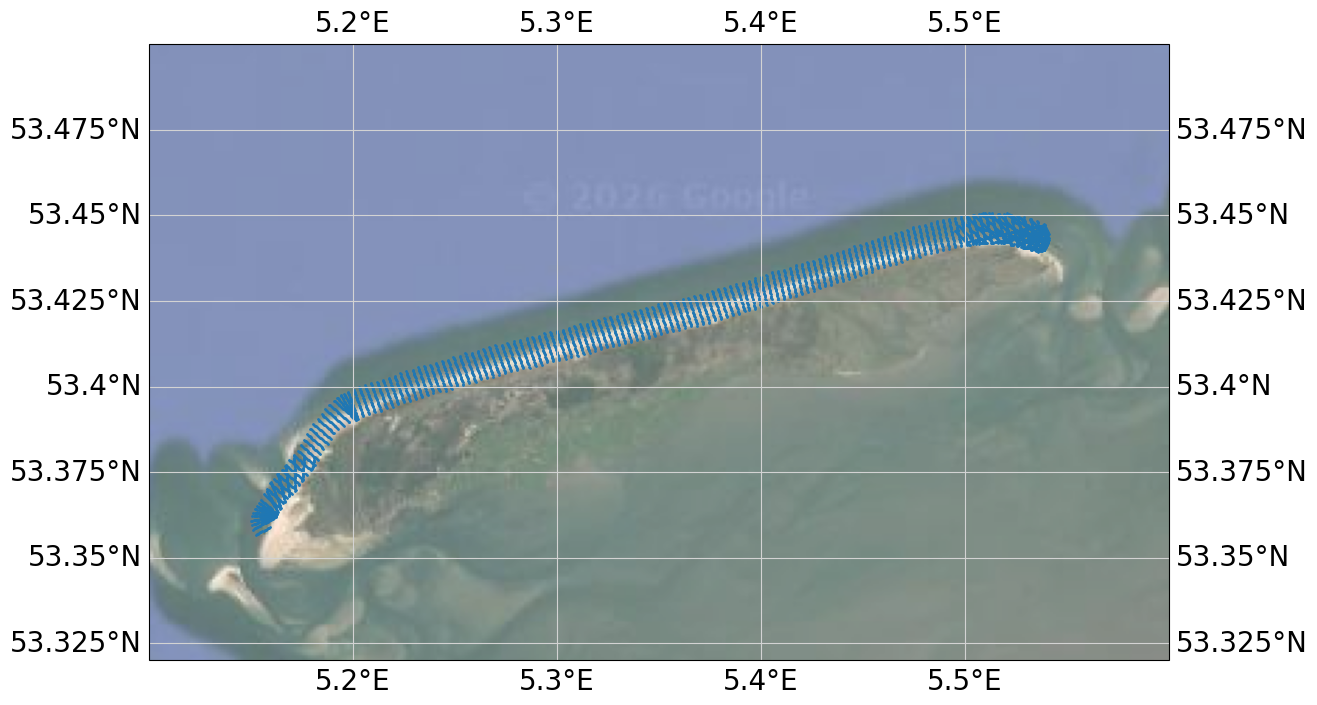

In [17]:
%matplotlib inline

# projection = ccrs.epsg('28992')
projection = ccrs.PlateCarree()

request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.scatter(jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, s=1, transform=projection)

### Transect polygons

In [20]:
transect_polys = pickle.load(open(path_transect_polys + 'transect_polys.pkl', 'rb'))

## Define areas for volume changes

## Functions for volume changes

In [20]:
def volume_changes(x_state, x_state_s, jarkus_gdf, poly_all, poly_west, poly_center, poly_east):
    start_time = time.perf_counter()
    
    # Volumes for all (sub)areas
    year_list = [int(_) for _ in kf_interp.drop(columns='geometry').columns]

    volumes = pd.DataFrame(index=year_list)

    volumes['kf_all'] = CD_geometry.compute_volume_changes(x_state, poly_all, col_name='', epsg_out=28992)
    volumes['rts_all'] = CD_geometry.compute_volume_changes(x_state_s, poly_all, col_name='', epsg_out=28992)
    volumes['jarkus_all'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_all, col_name='', epsg_out=28992)

    volumes['kf_west'] = CD_geometry.compute_volume_changes(x_state, poly_west, col_name='', epsg_out=28992)
    volumes['rts_west'] = CD_geometry.compute_volume_changes(x_state_s, poly_west, col_name='', epsg_out=28992)
    volumes['jarkus_west'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_west, col_name='', epsg_out=28992)

    volumes['kf_center'] = CD_geometry.compute_volume_changes(x_state, poly_center, col_name='', epsg_out=28992)
    volumes['rts_center'] = CD_geometry.compute_volume_changes(x_state_s, poly_center, col_name='', epsg_out=28992)
    volumes['jarkus_center'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_center, col_name='', epsg_out=28992)

    volumes['kf_east'] = CD_geometry.compute_volume_changes(x_state, poly_east, col_name='', epsg_out=28992)
    volumes['rts_east'] = CD_geometry.compute_volume_changes(x_state_s, poly_east, col_name='', epsg_out=28992)
    volumes['jarkus_east'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_east, col_name='', epsg_out=28992)

    volumes = volumes.drop([2001, 2003])

    # Volume timeseries statistics
    rmse = {}
    corr = {}
    pvalues = {}

    variables = ['all', 'west', 'center', 'east']

    for variable in variables:
        rmse[variable] = CD_statistics.RMSE_timeseries(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])
        corr[variable], pvalues[variable] = stats.pearsonr(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])

    # Volume timeseries trends
    trends = {}
    Cxxs = {}
    vs = {}

    variables = ['kf_all', 'rts_all', 'jarkus_all',
                 'kf_west', 'rts_west', 'jarkus_west',
                 'kf_center', 'rts_center', 'jarkus_center',
                 'kf_east', 'rts_east', 'jarkus_east']

    for variable in variables:
        trends[variable], Cxxs[variable], vs[variable] = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[variable].values)

    # Trend error (from VLM notebook)
    # Quntile of t-distribution
    alpha = 0.05
    f = len(volumes) - 1  # degrees of freedom
    quantile = stats.t.ppf(alpha, f)

    n = len(volumes)

    def compute_std(v):
        return np.sqrt(np.sum((v ** 2)) / (n - 1))

    errors = {}
    for key, value in vs.items():
        errors[key] = quantile * (compute_std(value) / np.sqrt(n))

    # Alternative, taking std from least-squares estimate covariance matrix: Cxx[0,0]
    # results in magnitudes 1e9
    # quantile*(Cxxs['kf_all'][0,0]/np.sqrt(n))

    end_time = time.perf_counter()
    ex_time = end_time - start_time
    print("Volume changes done. Needed ", round(ex_time,1), "seconds.")
       
    return volumes, rmse, corr, pvalues, trends, errors

## Tune

In [21]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [22]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


In [ ]:
# try to include trend
if new_tuning:
    year_ref = 2006
    n_iter = 2
    
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Store statistics for volume time series in DataFrames
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()

    # Store statistics for elevation time series in xarray DataSet
    # Initialise xarray DataSet to store the full map for all statistics and each combination of parameters
    lon = jarkus_gdf.geometry.x
    lat = jarkus_gdf.geometry.y
    
    empty_array = np.full([len(lon), len(sigma_l_values), len(factors), len(std_init_values)], np.nan)
    
    # Initialise the stats (collect all maps for all parameters) with NaN values
    all_stats = xr.Dataset(
                data_vars={
                    'std_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'rmse':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'corr':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'pvalue':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'trend_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy())
                },
                coords={
                    'lon':(['lon'], lon),
                    'lat':(['lat'], lat),
                    'sigma_l':(['sigma_l'], sigma_l_values),
                    'factors':(['factors'], factors),
                    'std_init':(['std_init'], std_init_values)
                })
    
    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')        
        
        # Initialise state vector
        init_df = init.to_dataframe()
        x = init_df.index.get_level_values('x')
        y = init_df.index.get_level_values('y')    
        x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
        x_state = x_state.set_crs(epsg)

        # Covariance matrix of the initial state
        sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
        sigma_xx_init = diags_array(sigma_xx_init_df.sigma)

        # "Iteration 0"
        x_k = x_state['init'].copy()
        sigma_xx_k = sigma_xx_init

        # Initial trend 
        trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

        for j in range(0, n_iter):
            x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
                  x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
                  seg_length, alt, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
                  max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)

            # New trend
            trends[f'trend_{j}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
            # Overwrite  trend_k for next iteration
            trends['trend_k'] = trends[f'trend_{j}'].copy()

            # Overwrite x_k so that next iteration starts with residuals and not the full signal
            x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
            sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

        # Re-add trend
        x_state_readd = x_state.copy()
        x_state_s_readd = x_state_s.copy()

        all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
        trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

        year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
        for year in year_list:
            deltaYear = year - year_ref
            x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
            x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
            x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

        kf_interp, rts_interp = CD_kalman.interpolate_results(jarkus_gdf, x_state_readd, x_state_s_readd)

 
        # Volume change time series
        volumes, rmse, corr, pvalues, trends, errors = volume_changes(kf_interp, rts_interp, jarkus_gdf,
                                                                     poly_all, poly_west, poly_center, poly_east)
        
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]
        errors_df[i] = pd.DataFrame([errors]).T[0]
    
    rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
    errors_df.to_pickle(path_output+'partun_volumes_errors.pkl')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    errors_df = pd.read_pickle(path_output+'partun_volumes_errors.pkl')
    print("Loaded files.")

    all_stats = xr.open_dataset(f'{path_output}partun_elevs_all_stats.nc')
    print(f'Loaded {path_output}partun_elevs_all_stats.nc')

0: factor = 1, sigma_l = 0.032015621187164243, std_init = 1


/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_combine_data.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_gdf = pd.concat([combined_gdf, gdf_temp])


Forward run done. Needed  1255.9 seconds.


/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_combine_data.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_gdf = pd.concat([combined_gdf, gdf_temp])


Forward run done. Needed  1479.4 seconds.


## Plots

In [ ]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
# c_list = ['purple', 'darkblue', 'limegreen'] # encode sigma_q (factors of sigma_l) with colour
ls_list = ['-', '-.', ':'] # encode sigma_gebco with linestyle

In [ ]:
def plot_legend(ax, c_list, ls_list, factors, std_init_values):
    legend_elements = [
        Line2D([0], [0], color='none', label='$\\bf{Color: \\sigma_q}$', lw=0, ms=0),  # Subtitle
        
        Line2D([0], [0], color=c_list[0], label=f'$\\sigma_{{q}}$ = {factors[0]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[1], label=f'$\\sigma_{{q}}$ = {factors[1]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[2], label=f'$\\sigma_{{q}}$ = {factors[2]}$\\cdot \\sigma_{{obs}}$ m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space
        Line2D([0], [0], color='none', label='$\\bf{Linestyle: \\sigma_{{init}}}$', lw=0, ms=0),  # Subtitle

        Line2D([0], [0], color='grey', ls=ls_list[0], label=f'$\\sigma_{{init}}$ = {std_init_values[0]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[1], label=f'$\\sigma_{{init}}$ = {std_init_values[1]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[2], label=f'$\\sigma_{{init}}$ = {std_init_values[2]} m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space

        # Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(2.95,1))

### Volume changes

In [ ]:
def plot_vol_stats(ax, data, area, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            idx, = np.where((param_df.factor == factor) & (param_df.std_init == std_init))
            ax.plot(param_df.loc[idx, 'sigma_l'], data[idx], ls=ls_list[g], c=c_list[f], marker='.')
            
            if corr:
                pvalues_box = np.where(pvalues_df.T.loc[idx, area] < 0.05)[0]
                ax.plot(param_df.loc[idx[pvalues_box], 'sigma_l'], corr_df.loc[area,idx[pvalues_box]].values,
                        marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')])#, loc='lower right')

            if plot_zero:
                ax.axhline(y=0, color='grey')            

    if ylim != None:
        ax.set_ylim(ylim[0], ylim[1])

    # if not corr:
    #     ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        # ax.ticklabel_format(useOffset=False, style='plain')
    
    ax.set_xlabel(r'$\sigma_{l}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=22)
    ax.grid()

In [ ]:
def mark_selected_param(ax, idx_selected, data):
    params_selected = param_df.iloc[idx_selected]
    ax.plot(params_selected['sigma_l'], data.iloc[idx_selected], 'o', c='None', markeredgecolor='red', ms=10, markeredgewidth=2)

#### Remove height difference between validation and new DTM
with bias from notebook 13

In [ ]:
bias = pickle.load(open(path_output + 'bias.pkl', 'rb'))
jarkus_red = jarkus_gdf.copy()
jarkus_red.loc[:, jarkus_red.columns != 'geometry'] += bias

#### Percentages

In [ ]:
vol_jarkus = pd.DataFrame()
vol_jarkus['all'] = CD_geometry.compute_volume_changes(jarkus_red, poly_all, col_name='', epsg_out=28992)
vol_jarkus['west'] = CD_geometry.compute_volume_changes(jarkus_red, poly_west, col_name='', epsg_out=28992)
vol_jarkus['center'] = CD_geometry.compute_volume_changes(jarkus_red, poly_center, col_name='', epsg_out=28992)
vol_jarkus['east'] = CD_geometry.compute_volume_changes(jarkus_red, poly_east, col_name='', epsg_out=28992)
vol_jarkus = vol_jarkus.drop([2001, 2002, 2003, 2012])

In [ ]:
trend_diff_perc = pd.DataFrame(columns=['all', 'west', 'center', 'east'], index=param_df.index)
rmse_perc = pd.DataFrame()
trend_diff = pd.DataFrame()

x = vol_jarkus.index.values.astype(int)

for area in vol_jarkus.columns:
    trend_jarkus, _, _ = CD_statistics.compute_trend_with_error(x, vol_jarkus[area])
    trend_diff[area] = trend_df.T[f'rts_{area}'] - trend_df.T[f'jarkus_{area}']
    
    # Find the parameter combinations where both trends have the same sign
    idx_pos, = np.where(np.sign(trend_df.T[f'rts_{area}']) == np.sign(trend_df.T[f'jarkus_{area}']))
    idx_neg, = np.where(np.sign(trend_df.T[f'rts_{area}']) != np.sign(trend_df.T[f'jarkus_{area}']))
    
    # Same sign: Quotient of absolute trends
    trend_diff_perc.loc[idx_pos,area] = (np.abs(trend_diff.loc[idx_pos, area]) / np.abs(trend_jarkus)) * 100
    # Different sign: Trend diff perc should end up with negative sign
    trend_diff_perc.loc[idx_neg,area] = (trend_diff.loc[idx_neg, area] / trend_jarkus) * 100
    
    rmse_perc[area] = (rmse_df.T[area]/np.mean(vol_jarkus[area])) * 100

In [ ]:
# idx_selected = 20 # index of the parameters selected for validation
# idx_selected = 4
idx_selected = 19

fig, axs = plt.subplots(4,3, figsize=(20,18))
fig.tight_layout()
fig.subplots_adjust(hspace=.25, wspace=.28)

## Absolute trend differences
# plot_vol_stats(axs[0,0], trend_diff['all'], area='all', ylabel=r'[m$^3$/year]', title='Trend difference', plot_zero=True)
# plot_vol_stats(axs[1,0], trend_diff['west'], area='west', ylabel=r'[m$^3$/year]', title='', plot_zero=True)
# plot_vol_stats(axs[2,0], trend_diff['center'], area='center', ylabel=r'[m$^3$/year]', title='', plot_zero=True)
# plot_vol_stats(axs[3,0], trend_diff['east'], area='east', ylabel=r'[m$^3$/year]', title='', plot_zero=True)

## Relative trend differences (%)
plot_vol_stats(axs[0,0], trend_diff_perc['all'], area='all', ylabel='% of total volume trend', title='Trend difference', plot_zero=False, ylim=None)
plot_vol_stats(axs[1,0], trend_diff_perc['west'], area='west', ylabel='% of total volume trend', title='', plot_zero=False)
plot_vol_stats(axs[2,0], trend_diff_perc['center'], area='center', ylabel='% of total volume trend', title='', plot_zero=False)
plot_vol_stats(axs[3,0], trend_diff_perc['east'], area='east', ylabel='% of total volume trend', title='', plot_zero=False)

mark_selected_param(axs[0,0], idx_selected, trend_diff_perc['all'])
mark_selected_param(axs[1,0], idx_selected, trend_diff_perc['west'])
mark_selected_param(axs[2,0], idx_selected, trend_diff_perc['center'])
mark_selected_param(axs[3,0], idx_selected, trend_diff_perc['east'])

axs[0,0].text(-.55,.5, f'Entire\ncoastline', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(-.5,.5, f'West', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(-.5,.5, f'Centre', transform=axs[2,0].transAxes, fontsize=20)
axs[3,0].text(-.5,.5, f'East', transform=axs[3,0].transAxes, fontsize=20)

# Absolute RMSE
# plot_vol_stats(axs[0,1], rmse_df.T['all'], area='all', ylabel=r'[m$^3$]', title='RMSE')
# plot_vol_stats(axs[1,1], rmse_df.T['west'], area='west', ylabel=r'[m$^3$]', title='')
# plot_vol_stats(axs[2,1], rmse_df.T['center'], area='center', ylabel=r'[m$^3$]', title='')
# plot_vol_stats(axs[3,1], rmse_df.T['east'], area='east', ylabel=r'[m$^3$]', title='')

# mark_selected_param(axs[0,1], idx_selected, rmse_df.T['all'])
# mark_selected_param(axs[1,1], idx_selected, rmse_df.T['west'])
# mark_selected_param(axs[2,1], idx_selected, rmse_df.T['center'])
# mark_selected_param(axs[3,1], idx_selected, rmse_df.T['east'])

# Relative RMSE (%)
ylim_rmse = [0,0.26]
ylim_rmse = None
plot_vol_stats(axs[0,1], rmse_perc['all'], area='all', ylabel='% of mean volume', title='RMSE', ylim=ylim_rmse)
plot_vol_stats(axs[1,1], rmse_perc['west'], area='west', ylabel='% of mean volume', title='', ylim=ylim_rmse)
plot_vol_stats(axs[2,1], rmse_perc['center'], area='center', ylabel='% of mean volume', title='', ylim=ylim_rmse)
plot_vol_stats(axs[3,1], rmse_perc['east'], area='east', ylabel='% of mean volume', title='', ylim=ylim_rmse)

mark_selected_param(axs[0,1], idx_selected, rmse_perc['all'])
mark_selected_param(axs[1,1], idx_selected, rmse_perc['west'])
mark_selected_param(axs[2,1], idx_selected, rmse_perc['center'])
mark_selected_param(axs[3,1], idx_selected, rmse_perc['east'])

ylim_corr = [-1,1]
# ylim_corr = None
plot_vol_stats(axs[0,2], corr_df.T['all'], area='all', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
plot_vol_stats(axs[1,2], corr_df.T['west'], area='west', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_vol_stats(axs[2,2], corr_df.T['center'], area='center', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_vol_stats(axs[3,2], corr_df.T['east'], area='east', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)

mark_selected_param(axs[0,2], idx_selected, corr_df.T['all'])
mark_selected_param(axs[1,2], idx_selected, corr_df.T['west'])
mark_selected_param(axs[2,2], idx_selected, corr_df.T['center'])
mark_selected_param(axs[3,2], idx_selected, corr_df.T['east'])

plot_legend(axs[0,1], c_list, ls_list, factors, std_init_values)
plt.suptitle('Terschelling: Sensitivity analysis with time series of volume changes', y=1.03, fontsize=25);

plt.savefig(f'{path_output}Ters_partun_volume_change_stats_full.png', dpi=300, bbox_inches='tight')

#### Split figure

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.25, wspace=.27)

plot_vol_stats(axs[0], trend_diff_perc['all'], area='all', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[0], idx_selected, trend_diff_perc['all'])

plot_vol_stats(axs[1], rmse_perc['all'], area='all', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[1], idx_selected, rmse_perc['all'])

plot_vol_stats(axs[2], corr_df.T['all'], area='all', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[2], idx_selected, corr_df.T['all'])

plot_legend(axs[1], c_list, ls_list, factors, std_init_values)
plt.suptitle('Terschelling entire coastline', y=1.15, fontsize=25);

plt.savefig(f'{path_output}Ters_partun_volume_change_stats_onlyEntireCoastline.png', dpi=300, bbox_inches='tight')

### Elevation changes

In [ ]:
def plot_elev_stats(ax, stats_data, stats_varname, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            ax.plot(stats_data.sigma_l, stats_data[stats_varname].loc[{'factors':factor, 'std_init':std_init}].median(dim='lon'), ls=ls_list[g], c=c_list[f], marker='.')
            if corr:
                pvalues_box = np.where(stats_data.pvalue.loc[{'factors':factor, 'std_init':std_init}].mean(dim='lon') < 0.05)[0]
                ax.plot(stats_data.sigma_l[idx[pvalues_box]], stats_data.corr.loc[{'factors':factor, 'std_init':std_init}].median(dim='lon')[idx[pvalues_box]], 
                marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')], loc='lower right')
            if ylim is not None:
                ax.set_ylim(ylim)
            if plot_zero:
                ax.axhline(y=0, color='grey')
    ax.set_xlabel(r'$\sigma_{obs}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()

In [ ]:
poly_west = pickle.load(open(path_output + f'poly_west_{epsg}.pkl', 'rb'))
poly_center = pickle.load(open(path_output + f'poly_center{epsg}.pkl', 'rb'))
poly_east = pickle.load(open(path_output + f'poly_east{epsg}.pkl', 'rb'))

stats_loc = gpd.GeoDataFrame(geometry=gpd.points_from_xy(all_stats.lon, all_stats.lat))

idx_west, = np.where(stats_loc.intersects(poly_west))
idx_center, = np.where(stats_loc.intersects(poly_center))
idx_east, = np.where(stats_loc.intersects(poly_east))

In [ ]:
fig, axs = plt.subplots(4,3, figsize=(20,18))
fig.tight_layout()
fig.subplots_adjust(hspace=.26, wspace=.23)

# ylim_tdiff = [-.05, .05]
ylim_tdiff = None
plot_elev_stats(axs[0,0], all_stats, 'trend_diff', ylabel='[m/year]', title='Trend difference', plot_zero=False, ylim=ylim_tdiff)
plot_elev_stats(axs[1,0], all_stats.isel(lon=idx_west), 'trend_diff', ylabel='[m/year]', title='', plot_zero=False, ylim=ylim_tdiff)
plot_elev_stats(axs[2,0], all_stats.isel(lon=idx_center), 'trend_diff', ylabel='[m/year]', title='', plot_zero=False, ylim=ylim_tdiff)
plot_elev_stats(axs[3,0], all_stats.isel(lon=idx_east), 'trend_diff', ylabel='[m/year]', title='', plot_zero=False, ylim=ylim_tdiff)

axs[0,0].text(-.55,.5, f'Entire\ncoastline', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(-.45,.5, f'West', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(-.45,.5, f'Center', transform=axs[2,0].transAxes, fontsize=20)
axs[3,0].text(-.45,.5, f'East', transform=axs[3,0].transAxes, fontsize=20)

# ylim_rmse = [.4,.7]
ylim_rmse = None
plot_elev_stats(axs[0,1], all_stats, 'rmse', ylabel='[m]', title='RMSE', ylim=ylim_rmse)
plot_elev_stats(axs[1,1], all_stats.isel(lon=idx_west), 'rmse', ylabel='[m]', title='', ylim=ylim_rmse)
plot_elev_stats(axs[2,1], all_stats.isel(lon=idx_center), 'rmse', ylabel='[m]', title='', ylim=ylim_rmse)
plot_elev_stats(axs[3,1], all_stats.isel(lon=idx_east), 'rmse', ylabel='[m]', title='', ylim=ylim_rmse)

# ylim_corr = [-.7,.7]
ylim_corr = None
plot_elev_stats(axs[0,2], all_stats, 'corr', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
plot_elev_stats(axs[1,2], all_stats.isel(lon=idx_west), 'corr', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_elev_stats(axs[2,2], all_stats.isel(lon=idx_center), 'corr', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_elev_stats(axs[3,2], all_stats.isel(lon=idx_east), 'corr', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)

plot_legend(axs[0,1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Terschelling: Sensitivity analysis with time series of elevation changes', y=1.03, fontsize=25);

plt.savefig(f'{path_output}Ters_partun_elev_change_stats.png', dpi=300, bbox_inches='tight')

#### Split figure

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.26, wspace=.23)

# ylim_tdiff = [-.05, .05]
ylim_tdiff = None
plot_elev_stats(axs[0], all_stats, 'trend_diff', ylabel='[m/year]', title='Trend difference', plot_zero=True, ylim=ylim_tdiff)

# ylim_rmse = [.4,.7]
ylim_rmse = None
plot_elev_stats(axs[1], all_stats, 'rmse', ylabel='[m]', title='RMSE', ylim=ylim_rmse)

ylim_corr = [0,.4]
plot_elev_stats(axs[2], all_stats, 'corr', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)

plot_legend(axs[1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Terschelling: Sensitivity analysis with time series of elevation changes', y=1.07, fontsize=25);

# plt.savefig(f'{path_output}Ters_entire_coastline_partun_elev_change_stats.png', dpi=300, bbox_inches='tight')